In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [17]:
df = pd.read_csv("/Users/saif/Desktop/ML_Load_Forecasting/data/Gold/df_features_fourier_time_encoding.csv", index_col=0 , parse_dates=True)

print(df.head(2))

                      Load_MW  temperature_2m  wind_speed_10m  \
2020-01-07 23:00:00  55818.41             3.0            15.5   
2020-01-08 00:00:00  54220.74             2.5            15.9   

                     shortwave_radiation  hour  dayofweek  month  is_weekend  \
2020-01-07 23:00:00                  0.0    23          1      1           0   
2020-01-08 00:00:00                  0.0     0          2      1           0   

                     hour_sin  hour_cos  ...  month_sin  month_cos  \
2020-01-07 23:00:00 -0.258819  0.965926  ...        0.5   0.866025   
2020-01-08 00:00:00  0.000000  1.000000  ...        0.5   0.866025   

                     is_holiday  lag_hour   lag_day  lag_week  \
2020-01-07 23:00:00           0  54220.74  51875.48  57004.20   
2020-01-08 00:00:00           0  52752.95  49243.74  53772.35   

                     rolling_mean_24h  rolling_mean_168h  rolling_std_24h  \
2020-01-07 23:00:00      64713.215833       55537.921071      8552.620952   
20

In [18]:
print(tf.__version__)

2.16.2


In [19]:
X = df.drop(columns=["Load_MW"])
y = df["Load_MW"]

X_train = X[X.index.year < 2023]
y_train = y[y.index.year < 2023]

X_test = X[X.index.year == 2023]
y_test = y[y.index.year == 2023]

#### Create Sequence

In [ ]:
def create_sequences(X, y, window=24):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i-window:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

# Numpy Arrays
X_arr = X_train.values
y_arr = y_train.values

X_seq, y_seq = create_sequences(X_arr, y_arr, window=24)
print(f"X_seq shape: {X_seq.shape}")   
print(f"y_seq shape: {y_seq.shape}")   

X_seq shape: (26113, 24, 21)
y_seq shape: (26113,)


#### Normalized

In [21]:
from sklearn.preprocessing import StandardScaler

scaler_lstm = StandardScaler()
X_seq_2d = X_seq.reshape(-1, X_seq.shape[-1])
X_seq_scaled = scaler_lstm.fit_transform(X_seq_2d).reshape(X_seq.shape)

scaler_y_lstm = StandardScaler()
y_seq_scaled = scaler_y_lstm.fit_transform(y_seq.reshape(-1, 1)).ravel()

#### Test Sequence

In [22]:
X_test_arr = X_test.values
y_test_arr = y_test.values

X_test_seq, y_test_seq = create_sequences(X_test_arr, y_test_arr, window=24)
X_test_seq_2d = X_test_seq.reshape(-1, X_test_seq.shape[-1])
X_test_seq_scaled = scaler_lstm.transform(X_test_seq_2d).reshape(X_test_seq.shape)

#### Build LSTM Modell 

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(24, 21)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.summary()

/Users/saif/Desktop/ML_Load_Forecasting/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 24, 64)         │        22,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,977 (136.63 KB)

 Trainable params: 34,977 (136.63 KB)

 Non-trainable params: 0 (0.00 B)

#### Training

In [24]:
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = model.fit(
    X_seq_scaled, y_seq_scaled,
    epochs          = 50,
    batch_size      = 32,
    validation_split= 0.1,
    callbacks       = [early_stop],
    verbose         = 1
)

Epoch 1/50
735/735 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 0.0844 - val_loss: 0.0251
Epoch 2/50
735/735 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.0290 - val_loss: 0.0164
Epoch 3/50
735/735 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0213 - val_loss: 0.0101
Epoch 4/50
735/735 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0175 - val_loss: 0.0079
Epoch 5/50
735/735 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.0144 - val_loss: 0.0075
Epoch 6/50
735/735 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - loss: 0.0121 - val_loss: 0.0055
Epoch 7/50
735/735 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - loss: 0.0104 - val_loss: 0.0049
Epoch 8/50
735/735 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - loss: 0.0087 - val_loss: 0.0040
Epoch 9/50
735/735 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - loss: 0.0075 - val_loss: 0.0040
Epoch 10/50
735/735 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 0.0066 - val_loss: 0.0064
Epoch 11/50
735/735 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.0057 - val_loss: 0.0033
Epoch 12/50
735/735 ━━━━━━━━━━

#### Evaluation

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_pred_lstm_scaled = model.predict(X_test_seq_scaled)
y_pred_lstm = scaler_y_lstm.inverse_transform(y_pred_lstm_scaled).ravel()

mae_lstm  = mean_absolute_error(y_test_seq, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_seq, y_pred_lstm))
r2_lstm   = r2_score(y_test_seq, y_pred_lstm)

print(f"LSTM → MAE: {mae_lstm:.0f} MW | RMSE: {rmse_lstm:.0f} MW | R²: {r2_lstm:.4f}")

268/268 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
LSTM → MAE: 371 MW | RMSE: 528 MW | R²: 0.9967


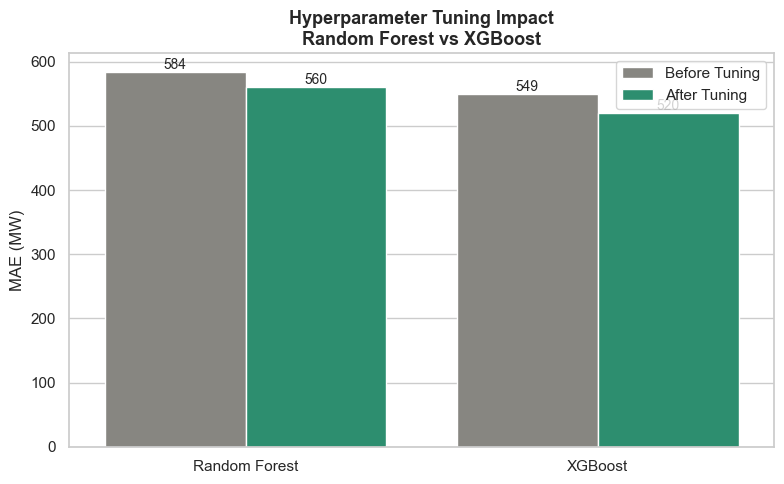

/var/folders/c2/0pncj6ld4glby0b51j0k8dgc0000gn/T/ipykernel_54404/2918029914.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final, x="Model", y="MAE",


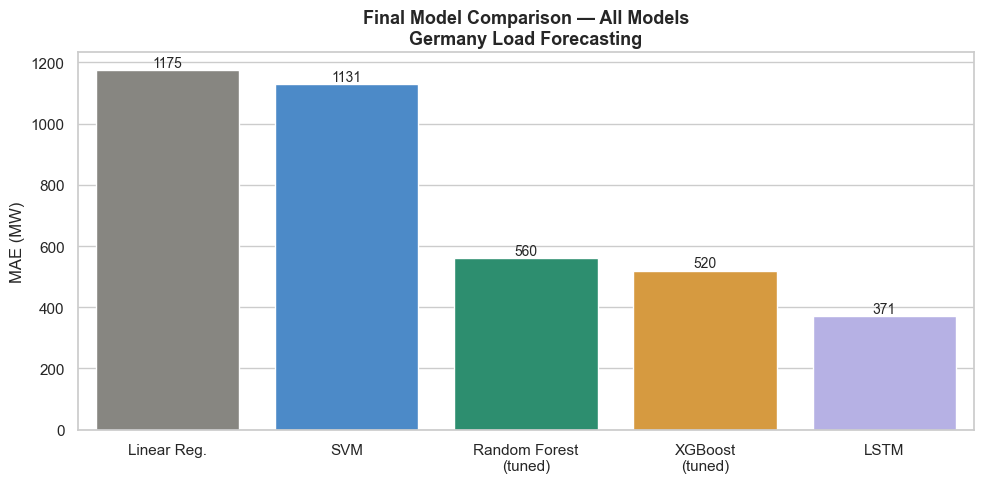

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_theme(style="whitegrid")

df_tuning = pd.DataFrame({
    "Model":  ["Random Forest", "Random Forest", "XGBoost", "XGBoost"],
    "MAE":    [584, 560, 549, 520],
    "Status": ["Before Tuning", "After Tuning", "Before Tuning", "After Tuning"]
})

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_tuning, x="Model", y="MAE",
            hue="Status",
            palette=["#888780", "#1D9E75"],
            ax=ax)

ax.set_title("Hyperparameter Tuning Impact\nRandom Forest vs XGBoost",
             fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("MAE (MW)")
ax.legend(title="")

for bar in ax.patches:
    height = bar.get_height()
    if height > 10:
        ax.text(bar.get_x() + bar.get_width()/2,
                height + 5,
                f"{int(height)}",
                ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("/Users/saif/Desktop/ML_Load_Forecasting/figures/08_tuning_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

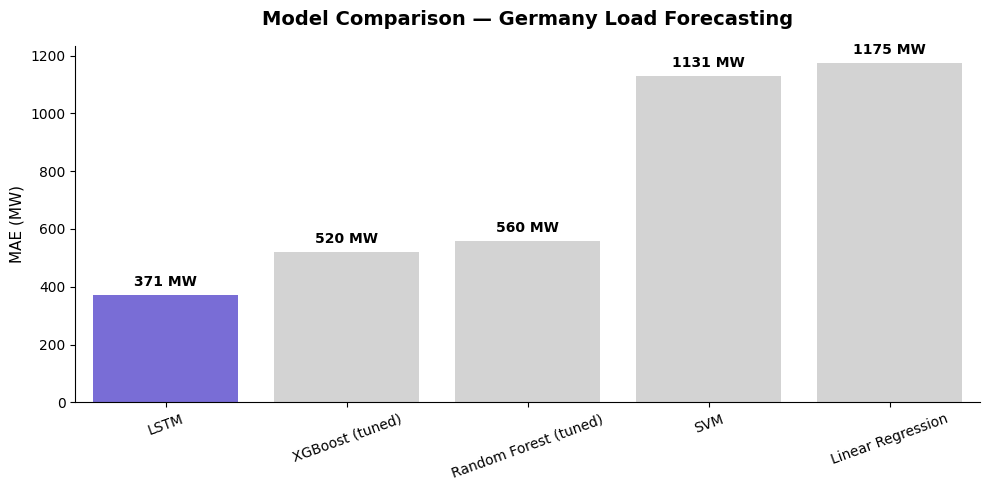

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# Data
# -------------------------
df_final = pd.DataFrame({
    "Model": ["Linear Regression", "SVM", 
              "Random Forest (tuned)", "XGBoost (tuned)", "LSTM"],
    "MAE":   [1175, 1131, 560, 520, 371],
})

# Sort (best = lowest error)
df_final = df_final.sort_values("MAE", ascending=True)

# Highlight best model
colors = []
for model in df_final["Model"]:
    if model == "LSTM":
        colors.append("#6C5CE7")  # highlight color
    else:
        colors.append("#D3D3D3")  # neutral grey

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=df_final,
    x="Model",
    y="MAE",
    hue="Model",           # required for palette (future seaborn)
    palette=colors,
    legend=False
)

# Titles
ax.set_title(
    "Model Comparison — Germany Load Forecasting",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_ylabel("MAE (MW)", fontsize=11)
ax.set_xlabel("")

# Rotate labels for readability
plt.xticks(rotation=20)

# -------------------------
# Annotations
# -------------------------
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 20,
        f"{int(height)} MW",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Remove top/right spines (clean look)
sns.despine()

plt.tight_layout()

# Save
plt.savefig(
    "/Users/saif/Desktop/ML_Load_Forecasting/figures/09_final_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()